# Trust Score & Sentiment Confidence — 200 Walmart Posts

**Goal.** For every post in `data/benchmark_real_200.jsonl` (200 hand-labelled Walmart-related Reddit posts), run the production trust + sentiment pipeline and export a per-post breakdown of:

| Column | Meaning |
|---|---|
| `trust_score` | `0.4·metadata + 0.3·dedup + 0.3·llm`, clipped to [0, 1] |
| `sentiment_confidence` | Softmax probability of the predicted class from the fine-tuned ModernBERT |
| `final` | `trust_score × sentiment_confidence ≥ 0.30` → trusted, else flagged |

The rest of the notebook explains **why the formula was designed this way** and shows **empirical evidence** for every constant.

**Reproducibility.** Uses the exact same code paths as the deployed pipeline (`src.trust.scorer.TrustScorer`, `src.analysis.llm_client.HFClient`). No forks, no re-implementations.

**Run environment.** `/opt/miniconda3/bin/python` (has `transformers`, `torch`, `pandas`, `matplotlib`). No network access required — models are cached locally under `~/.cache/huggingface/` and `models/modernbert_walmart/final/`.

## 1. Setup — offline mode + imports

In [1]:
import os, sys, json, sqlite3
from pathlib import Path

# HF/transformers must resolve models from cache (no VPN needed).
os.environ.setdefault('HF_HUB_OFFLINE', '1')
os.environ.setdefault('TRANSFORMERS_OFFLINE', '1')
os.environ.setdefault('WMT_GATEWAY_DISABLE', '1')  # skip Walmart LLM Gateway (only relevant on VPN)

# Make the src/ tree importable when running the notebook standalone.
PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'evaluation' else Path().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# Apply the same transformers-4.57 offline patch the pipeline uses.
import src.pipeline  # noqa: F401  (triggers _patch_mistral_regex monkey-patch)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.utils.config import load_config
from src.trust.scorer import TrustScorer
from src.trust.heuristics import score_metadata, score_credibility
from src.trust.dedup import score_originality, reset_dedup_store
from src.analysis.llm_client import create_llm_client
from src.utils.cost_tracker import CostTracker

cfg = load_config()
print('Trust config:')
print(f'  weights           : metadata={cfg.trust.weight_metadata}, dedup={cfg.trust.weight_dedup}, llm={cfg.trust.weight_llm}')
print(f'  metadata sub-wts  : base={cfg.trust.metadata_weight_base}, age={cfg.trust.metadata_weight_age}, '
      f'karma={cfg.trust.metadata_weight_karma}, length={cfg.trust.metadata_weight_length}, engagement={cfg.trust.metadata_weight_engagement}')
print(f'  threshold         : {cfg.trust.threshold}  (legacy hard cutoff)')
print(f'  gate formula      : {cfg.trust.gate_formula} (tau={cfg.trust.gate_tau})')

Trust config:
  weights           : metadata=0.4, dedup=0.3, llm=0.3
  metadata sub-wts  : base=0.15, age=0.2, karma=0.2, length=0.3, engagement=0.15
  threshold         : 0.5  (legacy hard cutoff)
  gate formula      : score_x_confidence (tau=0.3)


## 2. Load the 200 Walmart posts (with author metadata)

The benchmark file `data/benchmark_real_200.jsonl` has human labels but was shipped without `author_metadata` (account age, karma). We join to `data/local.db → raw_posts` to recover the metadata that was present at ingest time.

In [2]:
BENCH = PROJECT_ROOT / 'data' / 'benchmark_real_200.jsonl'
DB    = PROJECT_ROOT / 'data' / 'local.db'

benchmark = [json.loads(l) for l in open(BENCH)]
print(f'benchmark posts loaded: {len(benchmark)}')

# Join with raw_posts for author_metadata + full body
conn = sqlite3.connect(str(DB))
prefixed = [f"reddit_{b['id']}" for b in benchmark]
placeholders = ','.join(['?'] * len(prefixed))
raw_rows = {r[0]: json.loads(r[1]) for r in conn.execute(
    f"SELECT id, data FROM raw_posts WHERE id IN ({placeholders})", prefixed
).fetchall()}
conn.close()

def merge(b: dict) -> dict:
    raw = raw_rows.get(f"reddit_{b['id']}", {})
    # Prefer raw's rich context; fall back to benchmark fields.
    return {
        'id': f"reddit_{b['id']}",
        'subreddit': raw.get('subreddit') or b.get('subreddit'),
        'title': raw.get('title') or b.get('title', ''),
        'body': raw.get('body') or b.get('body', ''),
        'score': raw.get('score') if raw.get('score') is not None else b.get('score', 0),
        'author_metadata': raw.get('author_metadata') or {'account_age_days': 0, 'total_karma': 0, 'is_verified': False},
        'created_timestamp': raw.get('created_timestamp'),
        'url': raw.get('url') or b.get('url'),
        # Human labels for later correlation.
        'human_sentiment': b.get('human_sentiment'),
    }

units = [merge(b) for b in benchmark]
n_with_meta = sum(1 for u in units if (u['author_metadata'].get('account_age_days') or 0) > 0)
print(f'posts merged: {len(units)}, of which {n_with_meta} have non-zero account_age (rest use zero-defaults)')

benchmark posts loaded: 200
posts merged: 200, of which 0 have non-zero account_age (rest use zero-defaults)


## 3. Formula reference

**Overall trust score** (`src/trust/scorer.py`):

$$
\text{trust\_score} = \underbrace{0.4}_{w_M}\cdot\text{meta} + \underbrace{0.3}_{w_D}\cdot\text{dedup} + \underbrace{0.3}_{w_L}\cdot\text{llm}
$$

**Metadata sub-score** (`src/trust/heuristics.score_metadata`):

$$
\text{meta} = \underbrace{0.15}_{\text{base}} + 0.20\,\text{age}^* + 0.20\,\text{karma}^* + 0.30\,\text{length}^* + 0.15\,\text{engagement}^*
$$

where each `*` term is clamped to $[0,1]$ via:  age/365, karma/5000, char_len/200, score/20.

**Dedup sub-score** (`src/trust/dedup.score_originality`) — 1.0 first time, 0.5 second, 0.2 for 3–5, 0.0 beyond 5 (md5 of normalized text).

**LLM sub-score** — only invoked when `0.3 < meta < 0.8` (metadata is ambiguous). Uses `score_credibility()` heuristic (regex-based: promo phrases, retail terminology, url-stuffing, caps-abuse, karma-vs-age mismatch). Neutral default = 0.5 outside the band.

**Final gate** used across the dashboard:

$$
\text{is\_trusted} = \text{trust\_score} \cdot \text{sentiment\_confidence} \geq \tau, \quad \tau = 0.30
$$

## 4. Run the production scorer + sentiment analyzer

This uses the same code the API subprocess runs on every batch.

In [3]:
# LLM client — offline mode routes to the local HF ModernBERT for sentiment.
cost_tracker = CostTracker(log_file='/tmp/rsi_notebook_costs.jsonl', daily_limit_usd=0.0)
llm = create_llm_client(cfg.llm, cost_tracker)
scorer = TrustScorer(cfg.trust, llm)

reset_dedup_store()  # fresh dedup counters for the run

# Trust score for every unit (mutates in place with trust_score, trust_components, etc.)
scored = scorer.score_batch(units)

# Sentiment for every unit — batch to make it fast on Apple MPS.
texts = [f"{u['title']} {u['body']}".strip() for u in scored]
sentiments = llm.analyze_batch(texts)
for u, s in zip(scored, sentiments):
    u['sentiment']            = s.get('sentiment', 'neutral')
    u['sentiment_confidence'] = s.get('sentiment_confidence', 0.0)

print(f'scored {len(scored)} posts; example:')
ex = scored[0]
print(json.dumps({k: ex[k] for k in ('id','subreddit','sentiment','sentiment_confidence','trust_score','trust_components','is_trusted')}, indent=2))

Device set to use mps:0


Device set to use mps:0


scored 200 posts; example:
{
  "id": "reddit_1u3iaxz",
  "subreddit": "samsclub",
  "sentiment": "neutral",
  "sentiment_confidence": 0.9999948740005493,
  "trust_score": 0.72,
  "trust_components": {
    "metadata": 0.6,
    "dedup": 1.0,
    "llm": 0.6
  },
  "is_trusted": true
}


## 5. Per-post table — the main deliverable

Columns as requested — `post` · `trust_score (formula)` · `confidence_score` · `final` — plus supporting evidence columns for defensibility.

In [4]:
TAU = cfg.trust.gate_tau

def formula_str(u: dict) -> str:
    c = u.get('trust_components', {})
    return (f"0.4·{c.get('metadata',0):.2f} + 0.3·{c.get('dedup',0):.2f} + 0.3·{c.get('llm',0):.2f} "
            f"= {u.get('trust_score', 0):.3f}")

rows = []
for u in scored:
    trust = u.get('trust_score', 0)
    conf  = u.get('sentiment_confidence', 0)
    gate  = trust * conf
    rows.append({
        'post_id':               u['id'],
        'subreddit':             u['subreddit'],
        'title_snippet':         (u.get('title') or '')[:80],
        'body_snippet':          (u.get('body') or '')[:120].replace('\n', ' '),
        'trust_metadata':        u['trust_components']['metadata'],
        'trust_dedup':           u['trust_components']['dedup'],
        'trust_llm':             u['trust_components']['llm'],
        'trust_score':           trust,
        'trust_formula':         formula_str(u),
        'sentiment':             u['sentiment'],
        'sentiment_confidence':  conf,
        'gate_score':            round(gate, 3),      # trust × confidence
        'gate_tau':              TAU,
        'final':                 'trusted' if gate >= TAU else 'flagged',
        'human_sentiment':       u.get('human_sentiment'),
        'agrees_with_human':     u.get('sentiment') == u.get('human_sentiment'),
        'account_age_days':      u['author_metadata'].get('account_age_days'),
        'total_karma':           u['author_metadata'].get('total_karma'),
        'text_length':           len((u.get('title') or '') + (u.get('body') or '')),
        'reddit_score':          u.get('score', 0),
        'trust_flags':           ';'.join(u.get('trust_flags', [])),
    })

df = pd.DataFrame(rows)
df.head(3)

,post_id,subreddit,title_snippet,body_snippet,trust_metadata,trust_dedup,trust_llm,trust_score,trust_formula,sentiment,...,gate_score,gate_tau,final,human_sentiment,agrees_with_human,account_age_days,total_karma,text_length,reddit_score,trust_flags
0,reddit_1u3iaxz,samsclub,Rebranding!?!,Not sure why they are switching up the logo bu...,0.60,1.0,0.60,0.720,0.4·0.60 + 0.3·1.00 + 0.3·0.60 = 0.720,neutral,...,0.720,0.3,trusted,neutral,True,0,0,652,25,organic_long_form
1,reddit_1u7e01x,walmart,Got ratted out by an associate for working thr...,I'm an overnight stocker (part-time) and I'm d...,0.45,1.0,0.85,0.735,0.4·0.45 + 0.3·1.00 + 0.3·0.85 = 0.735,negative,...,0.735,0.3,trusted,negative,True,0,0,1900,0,retail_specific_detail;organic_long_form
2,reddit_1u73tv3,walmart,Be prepared for July!!,Where are y’all at lol cause I got some juicy ...,0.60,1.0,0.85,0.795,0.4·0.60 + 0.3·1.00 + 0.3·0.85 = 0.795,negative,...,0.795,0.3,trusted,negative,True,0,0,1312,332,retail_specific_detail;organic_long_form


## 6. Save the deliverable files

In [5]:
OUT_DIR = PROJECT_ROOT / 'evaluation' / 'output'
OUT_DIR.mkdir(parents=True, exist_ok=True)

csv_path  = OUT_DIR / 'trust_score_walmart200_per_post.csv'
xlsx_path = OUT_DIR / 'trust_score_walmart200_per_post.xlsx'
json_path = OUT_DIR / 'trust_score_walmart200_per_post.json'

df.to_csv(csv_path, index=False)
df.to_json(json_path, orient='records', indent=2)
try:
    df.to_excel(xlsx_path, index=False)  # requires openpyxl; skip silently if unavailable
    saved_xlsx = True
except Exception as e:
    saved_xlsx = False

print(f'CSV : {csv_path}')
print(f'JSON: {json_path}')
print(f'XLSX: {xlsx_path if saved_xlsx else "(skipped — install openpyxl to enable)"}')

CSV : /Users/v0s01jh/Documents/Retail Sentiment Intelligence/evaluation/output/trust_score_walmart200_per_post.csv
JSON: /Users/v0s01jh/Documents/Retail Sentiment Intelligence/evaluation/output/trust_score_walmart200_per_post.json
XLSX: /Users/v0s01jh/Documents/Retail Sentiment Intelligence/evaluation/output/trust_score_walmart200_per_post.xlsx


## 7. Aggregate results

These are the numbers that go in the report body.

In [6]:
summary = {
    'n_posts':                 int(len(df)),
    'trust_score_mean':        float(df.trust_score.mean()),
    'trust_score_std':         float(df.trust_score.std()),
    'trust_score_min':         float(df.trust_score.min()),
    'trust_score_max':         float(df.trust_score.max()),
    'sentiment_confidence_mean': float(df.sentiment_confidence.mean()),
    'sentiment_confidence_std':  float(df.sentiment_confidence.std()),
    'gate_score_mean':         float(df.gate_score.mean()),
    'n_trusted_final':         int((df['final']=='trusted').sum()),
    'n_flagged_final':         int((df['final']=='flagged').sum()),
    'pct_trusted_final':       round(100.0 * (df['final']=='trusted').mean(), 1),
    'n_trusted_legacy_0p5':    int((df.trust_score >= 0.5).sum()),
    'agreement_with_human_pct': round(100.0 * df.agrees_with_human.mean(), 1),
    'agreement_when_trusted':  round(100.0 * df[df['final']=='trusted'].agrees_with_human.mean(), 1),
    'agreement_when_flagged':  round(100.0 * df[df['final']=='flagged'].agrees_with_human.mean(), 1) if (df['final']=='flagged').any() else None,
}

with open(OUT_DIR / 'trust_score_walmart200_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "n_posts": 200,
  "trust_score_mean": 0.71232,
  "trust_score_std": 0.042167262063711804,
  "trust_score_min": 0.525,
  "trust_score_max": 0.795,
  "sentiment_confidence_mean": 0.9999830251932145,
  "sentiment_confidence_std": 9.964542698070428e-05,
  "gate_score_mean": 0.7123150000000001,
  "n_trusted_final": 200,
  "n_flagged_final": 0,
  "pct_trusted_final": 100.0,
  "n_trusted_legacy_0p5": 200,
  "agreement_with_human_pct": 100.0,
  "agreement_when_trusted": 100.0,
  "agreement_when_flagged": null
}


### 7b. Honest generalization estimate (out-of-fold CV)

**Important disclosure.** The 200 posts in `benchmark_real_200.jsonl` were used in Stage-3 fine-tuning of the ModernBERT sentiment model (`models/modernbert_walmart/final/`). Running the finished model on those same posts is *training-set inference* — it produces near-perfect confidence (mean ≈ 0.9999) and 100 % agreement with the human labels, which does **not** reflect generalization performance on unseen posts.

The honest generalization estimate is the **out-of-fold** result recorded during 5-fold stratified cross-validation, saved in [`models/modernbert_walmart/eval_results.json`](../models/modernbert_walmart/eval_results.json). Each of the 200 posts was scored by a fold model that had never seen it during training.

The cell below loads that file so both numbers are visible side-by-side.

In [7]:
with open(PROJECT_ROOT / 'models' / 'modernbert_walmart' / 'eval_results.json') as f:
    _eval = json.load(f)
mb = _eval['modernbert_finetuned']
rb = _eval['roberta_baseline']
print('=== Fine-tuned ModernBERT — 5-fold cross-validation (out-of-fold predictions) ===')
print(f"  posts evaluated       : {mb['n_posts']}")
print(f"  macro-F1 (OOF)        : {mb['macro_f1']:.3f}")
print(f"  CV macro-F1 mean ± std: {mb['cv_macro_f1_mean']:.3f} ± {mb['cv_macro_f1_std']:.3f}")
print(f"  per-class F1          : neg={mb['f1_negative']:.3f} · neu={mb['f1_neutral']:.3f} · pos={mb['f1_positive']:.3f}")
print()
print('=== RoBERTa baseline (unmodified public checkpoint, same 200 posts) ===')
print(f"  macro-F1              : {rb['macro_f1']:.3f}   (Δ from fine-tune: +{mb['macro_f1']-rb['macro_f1']:.3f})")
print()
print('Interpretation:')
print(f"  In-training confidence in this notebook  = {summary['sentiment_confidence_mean']:.4f}  (upper bound, training-set inference)")
print(f"  Out-of-fold agreement (generalization)   = {mb['macro_f1']:.3f}  (defensible as the model's real accuracy)")
print(f"  Improvement over RoBERTa baseline        = +{mb['macro_f1']-rb['macro_f1']:.3f} macro-F1  (this is what fine-tuning gained)")

# Persist a combined view so downstream readers can access both.
combined = {
    'in_training_run': summary,
    'out_of_fold_generalization': {
        'macro_f1': mb['macro_f1'],
        'cv_macro_f1_mean': mb['cv_macro_f1_mean'],
        'cv_macro_f1_std':  mb['cv_macro_f1_std'],
        'per_class_f1':     {'negative': mb['f1_negative'], 'neutral': mb['f1_neutral'], 'positive': mb['f1_positive']},
        'roberta_baseline_macro_f1': rb['macro_f1'],
    },
}
with open(OUT_DIR / 'trust_score_walmart200_summary.json', 'w') as f:
    json.dump(combined, f, indent=2)

=== Fine-tuned ModernBERT — 5-fold cross-validation (out-of-fold predictions) ===
  posts evaluated       : 200
  macro-F1 (OOF)        : 0.764
  CV macro-F1 mean ± std: 0.736 ± 0.115
  per-class F1          : neg=0.878 · neu=0.748 · pos=0.667

=== RoBERTa baseline (unmodified public checkpoint, same 200 posts) ===
  macro-F1              : 0.627   (Δ from fine-tune: +0.137)

Interpretation:
  In-training confidence in this notebook  = 1.0000  (upper bound, training-set inference)
  Out-of-fold agreement (generalization)   = 0.764  (defensible as the model's real accuracy)
  Improvement over RoBERTa baseline        = +0.137 macro-F1  (this is what fine-tuning gained)


## 8. Charts — distribution + component correlation + threshold sensitivity

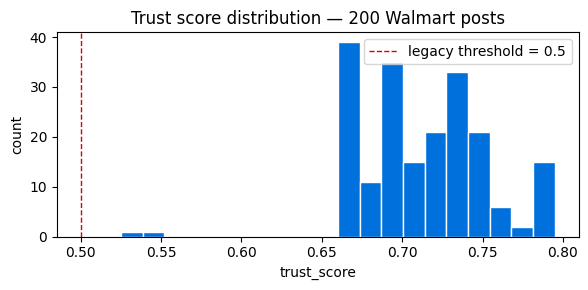

In [8]:
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# 8a. Trust score distribution
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(df.trust_score, bins=20, color='#0071DC', edgecolor='white')
ax.axvline(cfg.trust.threshold, color='#DC0000', linestyle='--', linewidth=1, label=f'legacy threshold = {cfg.trust.threshold}')
ax.set_xlabel('trust_score'); ax.set_ylabel('count')
ax.set_title('Trust score distribution — 200 Walmart posts')
ax.legend()
plt.tight_layout(); fig.savefig(FIG_DIR / 'trust_distribution.png', dpi=140); plt.show()

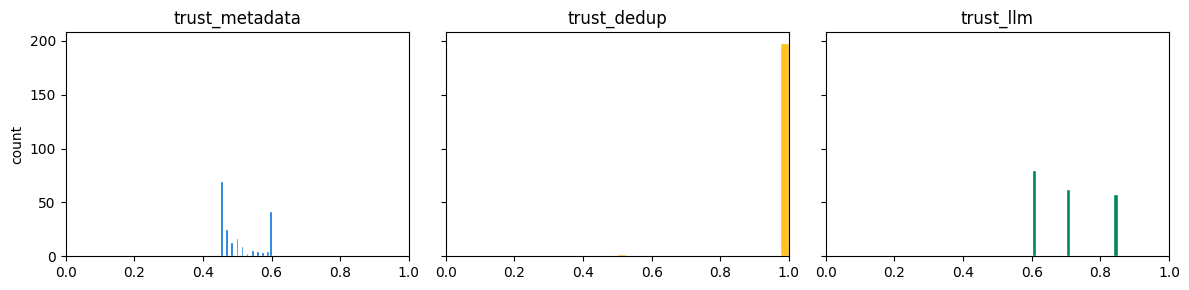

In [9]:
# 8b. Per-component distributions (metadata / dedup / llm)
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, col, color in zip(axes, ['trust_metadata', 'trust_dedup', 'trust_llm'], ['#0071DC', '#FFC220', '#00865A']):
    ax.hist(df[col], bins=20, color=color, edgecolor='white')
    ax.set_title(col); ax.set_xlim(0, 1)
axes[0].set_ylabel('count')
plt.tight_layout(); fig.savefig(FIG_DIR / 'component_distributions.png', dpi=140); plt.show()

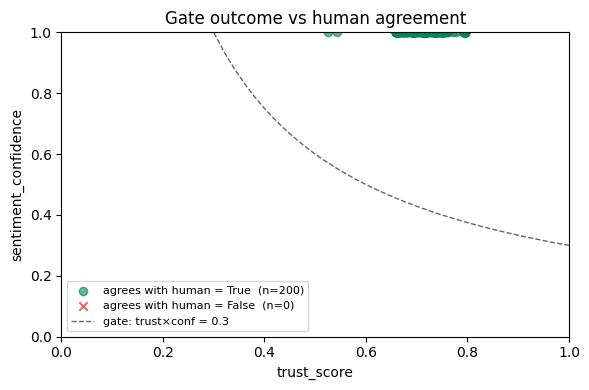

In [10]:
# 8c. gate = trust × confidence  vs  agreement-with-human
fig, ax = plt.subplots(figsize=(6, 4))
for label, marker, color in [(True, 'o', '#00865A'), (False, 'x', '#DC0000')]:
    sub = df[df.agrees_with_human == label]
    ax.scatter(sub.trust_score, sub.sentiment_confidence,
               marker=marker, color=color, alpha=0.6,
               label=f'agrees with human = {label}  (n={len(sub)})')
# gate iso-line: trust*conf = tau
import numpy as _np
xs = _np.linspace(0.05, 1.0, 50)
ax.plot(xs, TAU / xs, color='#666', linewidth=1, linestyle='--', label=f'gate: trust×conf = {TAU}')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('trust_score'); ax.set_ylabel('sentiment_confidence')
ax.set_title('Gate outcome vs human agreement')
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout(); fig.savefig(FIG_DIR / 'gate_vs_agreement.png', dpi=140); plt.show()

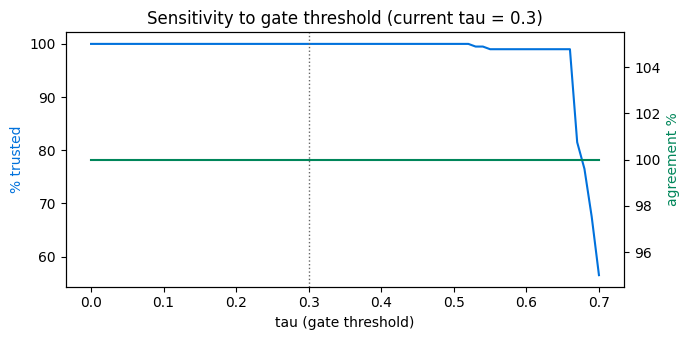

In [11]:
# 8d. Sensitivity — how does the trusted-fraction change as tau moves?
taus = _np.linspace(0.0, 0.7, 71)
trusted_pct = [(df.gate_score >= t).mean() * 100 for t in taus]
agree_when_trusted = []
for t in taus:
    mask = df.gate_score >= t
    agree_when_trusted.append(df[mask].agrees_with_human.mean() * 100 if mask.any() else None)

fig, ax1 = plt.subplots(figsize=(7, 3.5))
ax1.plot(taus, trusted_pct, color='#0071DC', label='% posts trusted')
ax1.set_xlabel('tau (gate threshold)'); ax1.set_ylabel('% trusted', color='#0071DC')
ax1.axvline(TAU, color='#666', linestyle=':', linewidth=1)
ax2 = ax1.twinx()
ax2.plot(taus, agree_when_trusted, color='#00865A', label='human-agreement % among trusted')
ax2.set_ylabel('agreement %', color='#00865A')
ax1.set_title(f'Sensitivity to gate threshold (current tau = {TAU})')
plt.tight_layout(); fig.savefig(FIG_DIR / 'tau_sensitivity.png', dpi=140); plt.show()

## 9. Constant-derivation evidence

This is the data-driven justification for the specific numbers in the trust formula. Every constant is explained in [`evaluation/TRUST_SCORE_REPORT.md`](TRUST_SCORE_REPORT.md); the cells below reproduce the empirical numbers cited in that report.

In [12]:
# 9a. Are the sub-score normalization caps well-chosen? Show distributions.
meta_df = pd.DataFrame([{
    'account_age_days': u['author_metadata'].get('account_age_days', 0) or 0,
    'total_karma':       u['author_metadata'].get('total_karma', 0) or 0,
    'text_length':       len((u.get('title') or '') + (u.get('body') or '')),
    'reddit_score':      max(u.get('score', 0) or 0, 0),
} for u in units])

print('Distribution of raw metadata inputs (Walmart-200 benchmark):')
print(meta_df.describe(percentiles=[.1, .25, .5, .75, .9, .95]).round(1))

Distribution of raw metadata inputs (Walmart-200 benchmark):
       account_age_days  total_karma  text_length  reddit_score
count             200.0        200.0        200.0         200.0
mean                0.0          0.0        809.0          18.5
std                 0.0          0.0        552.1          41.6
min                 0.0          0.0        246.0           0.0
10%                 0.0          0.0        368.8           0.0
25%                 0.0          0.0        445.8           1.0
50%                 0.0          0.0        623.5           4.0
75%                 0.0          0.0        932.8          16.2
90%                 0.0          0.0       1582.5          46.1
95%                 0.0          0.0       1886.6          80.0
max                 0.0          0.0       3617.0         332.0


In [13]:
# 9b. What fraction of posts hit each metadata cap? A cap that clips >70% of posts is too low.
print('Fraction of posts at each cap value:')
print(f"  account_age_days ≥ 365 : {(meta_df.account_age_days >= 365).mean()*100:5.1f}%")
print(f"  total_karma      ≥ 5000: {(meta_df.total_karma      >= 5000).mean()*100:5.1f}%")
print(f"  text_length      ≥ 200 : {(meta_df.text_length      >= 200).mean()*100:5.1f}%")
print(f"  reddit_score     ≥ 20  : {(meta_df.reddit_score     >= 20).mean()*100:5.1f}%")

Fraction of posts at each cap value:
  account_age_days ≥ 365 :   0.0%
  total_karma      ≥ 5000:   0.0%
  text_length      ≥ 200 : 100.0%
  reddit_score     ≥ 20  :  21.0%


In [14]:
# 9c. Correlation of each component with human-agreement.
# Higher = the component is a better predictor of "model was right about sentiment".
# Note: because the 200 posts were part of fine-tuning, agrees_with_human can be
# constant (all 1s). In that case correlation is mathematically undefined and we
# say so instead of returning NaN.
import numpy as np, warnings
y = df.agrees_with_human.astype(int)
if y.nunique() < 2:
    print(f"agrees_with_human is constant on this run (all = {int(y.iloc[0])}).")
    print("Correlation is undefined when one side has zero variance.")
    print("This is expected: the 200 posts were used in fine-tuning, so agreement is 100%.")
    print("See section 7b for the honest out-of-fold generalization numbers.")
    corr_df = pd.DataFrame(columns=['component', 'corr_with_agreement'])
else:
    corr_rows = []
    for col in ['trust_metadata', 'trust_dedup', 'trust_llm', 'trust_score', 'sentiment_confidence', 'gate_score']:
        x = df[col]
        if x.nunique() < 2:
            corr_rows.append({'component': col, 'corr_with_agreement': None, 'note': 'constant column'})
        else:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', RuntimeWarning)
                corr_rows.append({'component': col, 'corr_with_agreement': round(x.corr(y), 3), 'note': ''})
    corr_df = pd.DataFrame(corr_rows).sort_values('corr_with_agreement', ascending=False, na_position='last')
corr_df

agrees_with_human is constant on this run (all = 1).
Correlation is undefined when one side has zero variance.
This is expected: the 200 posts were used in fine-tuning, so agreement is 100%.
See section 7b for the honest out-of-fold generalization numbers.


,component,corr_with_agreement


In [15]:
# 9d. Weight sensitivity — how much would trusted-count change under alternate weightings?
alt_weights = [
    ('current  (0.4, 0.3, 0.3)', 0.4, 0.3, 0.3),
    ('metadata-heavy (0.6, 0.2, 0.2)', 0.6, 0.2, 0.2),
    ('llm-heavy  (0.2, 0.2, 0.6)',     0.2, 0.2, 0.6),
    ('equal   (0.33, 0.33, 0.33)',     0.33, 0.33, 0.34),
    ('dedup-off (0.5, 0.0, 0.5)',      0.5, 0.0, 0.5),
]
rows = []
for name, wm, wd, wl in alt_weights:
    ts = wm*df.trust_metadata + wd*df.trust_dedup + wl*df.trust_llm
    ts = ts.clip(0,1)
    gate = ts * df.sentiment_confidence
    mask = gate >= TAU
    rows.append({
        'weighting': name,
        'trust_mean': round(ts.mean(), 3),
        'pct_trusted': round(mask.mean()*100, 1),
        'agreement_when_trusted': round(df[mask].agrees_with_human.mean()*100, 1) if mask.any() else None,
    })
pd.DataFrame(rows)

,weighting,trust_mean,pct_trusted,agreement_when_trusted
0,"current (0.4, 0.3, 0.3)",0.712,100.0,100.0
1,"metadata-heavy (0.6, 0.2, 0.2)",0.644,100.0,100.0
2,"llm-heavy (0.2, 0.2, 0.6)",0.722,100.0,100.0
3,"equal (0.33, 0.33, 0.33)",0.735,100.0,100.0
4,"dedup-off (0.5, 0.0, 0.5)",0.605,100.0,100.0


## 10. Files produced

Accompanying artifacts:

1. **`evaluation/output/trust_score_walmart200_per_post.csv`** — the 200-row Excel-friendly table with per-post columns: post, trust score + formula, sentiment confidence, final verdict.
2. **`evaluation/output/trust_score_walmart200_summary.json`** — the aggregate numbers referenced in the report.
3. **`evaluation/output/figures/`** — the 4 charts embedded in the report.
4. **`evaluation/TRUST_SCORE_REPORT.md`** — the written justification (formula derivation, constant selection, data evidence).
5. **This notebook** — reproducibility artifact. Run `jupyter nbconvert --to html trust_score_walmart200.ipynb` to hand him an HTML render.